<a href="https://colab.research.google.com/github/jbeeksieu2023-del/ML-fundamentals-2026/blob/main/assignment_1_jade_beeksieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GitHub repository: https://github.com/jbeeksieu2023-del/ML-fundamentals-2026

**Task: Identifying the Prediction Target
Lecture material: Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection).
• Inspect the dataset and identify which column should be treated as the target variable for this assignment.
• Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign.
• Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective.**

It is important to first diagnose the business problem, to define a goal for our model. This means that we find the **right** solution to the goal.

**"Given client and campaign information available at the time of contact, predict whether
the client subscribes to a term deposit (i.e., a type of short-term investment)."**


From our business problem formulated above, our target variable wil be the column names "y".
This column answers booleanly, yes/no, to whether or not the clients have subscribed to a term deposit. This is a clear answer to the business question, and will allow us to predict based on marketing campaigns, its success directly - yes they have commited, no they have not.
Another variable which may appear as a target would be ...................


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Models and baseline
!pip install scikit-optimize

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)

# Bayesian Optimization
from skopt import BayesSearchCV
sns.set_theme(style="whitegrid")

# Suppress benign sklearn internal warnings
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.1 MB/s eta 0:00:00


In [2]:
def compute_metrics(y_true, y_pred, y_score=None):
    """Return a dict of standard classification metrics.
    y_score: predicted probabilities for the positive class (needed for ROC-AUC).
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test):
    df = pd.DataFrame({
        "Set": ["Train", "Validation", "Test"],
        "X shape": [X_train.shape, X_val.shape, X_test.shape],
        "y shape": [y_train.shape, y_val.shape, y_test.shape],
    })
    display(df.style.hide(axis="index"))


def display_metrics(name, metrics, decimals=4):
    print(f"\n{name}")
    df = pd.DataFrame([metrics]).round(decimals)
    display(df.style.hide(axis="index"))


def display_model_results(name, best_params, metrics, decimals=4):
    print(f"\n{name} — Best Parameters")
    display(pd.DataFrame([best_params]).style.hide(axis="index"))
    print(f"{name} — Validation Metrics")
    display(pd.DataFrame([metrics]).round(decimals).style.hide(axis="index"))


# Accumulator for the summary table
results_table = []

def add_result(name, split, metrics, best_params=None, notes=None):
    row = {
        "Model": name,
        "Split": split,
        "Accuracy": metrics.get("accuracy"),
        "Precision": metrics.get("precision"),
        "Recall": metrics.get("recall"),
        "F1": metrics.get("f1"),
        "ROC-AUC": metrics.get("roc_auc"),
        "Notes": notes,
    }
    if best_params:
        row["Best Params"] = ", ".join(f"{k}={v}" for k, v in best_params.items())
    else:
        row["Best Params"] = None
    results_table.append(row)


def show_results(sort_by=("Split", "ROC-AUC"), ascending=(True, False), decimals=4):
    df = pd.DataFrame(results_table)
    if df.empty:
        print("results_table is empty.")
        return df
    df_sorted = df.sort_values(list(sort_by), ascending=list(ascending))
    display(df_sorted.round(decimals).style.hide(axis="index"))
    return df_sorted

**Task: Data Loading and Exploration
Lecture material: Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection and EDA).
• Load the dataset into a Pandas DataFrame.
• Inspect the structure of the dataset: number of observations, number of features, data types, and basic
summary statistics.
• Identify which variables are numerical and which are categorical.
Individual Assignment I AI: Machine Learning Foundation
• Analyze the distribution of the target variable and comment on potential class imbalance.
• Detect explicit and implicit missing values (e.g., special categories such as unknown).
• Visualize the distribution of at least:
 –  two numerical variables; and
 –  two categorical variables.
• Identify at least one variable that may require special consideration before modeling (e.g., due to distributional
properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.
Note: Exploratory analysis is not a checklist of plots. Each visualization or statistic should support a specific
observation or hypothesis about the data.**

In [3]:
import pandas

In [6]:
df=pandas.read_csv("bank-additional.csv", sep=";")

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [ ]:
print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of features (columns): {df.shape[1]}")

Number of observations (rows): 4119
Number of features (columns): 21


In [ ]:
print("Data types and non-null counts:")
df.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  c

In [ ]:
print("Basic summary statistics for numerical columns:")
display(df.describe())

Basic summary statistics for numerical columns:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


We can gather some basic information about the dataset now. We have 4119 rows and 21 columns. From the columns, we have split them into two data types, numerical and categorial, shown above.

Distribution of target variable 'y':


,count
y,
no,3668
yes,451


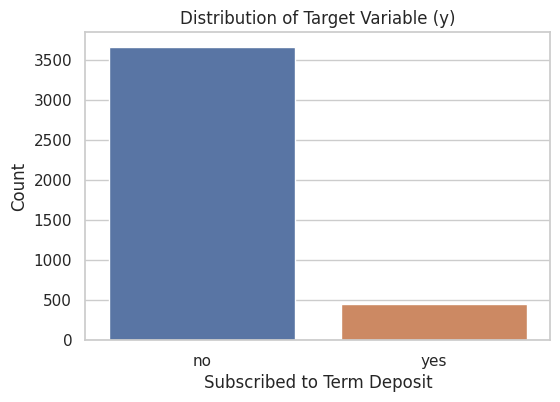


Percentage distribution of 'y':


,proportion
y,
no,89.05074
yes,10.94926


In [ ]:
# Distribution of the target variable 'y'
print("Distribution of target variable 'y':")
display(df['y'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, hue='y', legend=False)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

# Check for class imbalance
class_imbalance = df['y'].value_counts(normalize=True) * 100
print("\nPercentage distribution of 'y':")
display(class_imbalance)

In [ ]:
# Detect explicit missing values (NaN)
print("Explicit missing values (NaN) per column:")
display(df.isnull().sum())

# Detect implicit missing values (e.g., 'unknown') in categorical columns
print("\nImplicit missing values ('unknown') in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].unique():
        print(f"  - Column '{col}': {df[col].value_counts().get('unknown', 0)} occurrences")

Explicit missing values (NaN) per column:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Implicit missing values ('unknown') in categorical columns:
  - Column 'job': 39 occurrences
  - Column 'marital': 11 occurrences
  - Column 'education': 167 occurrences
  - Column 'default': 803 occurrences
  - Column 'housing': 105 occurrences
  - Column 'loan': 105 occurrences


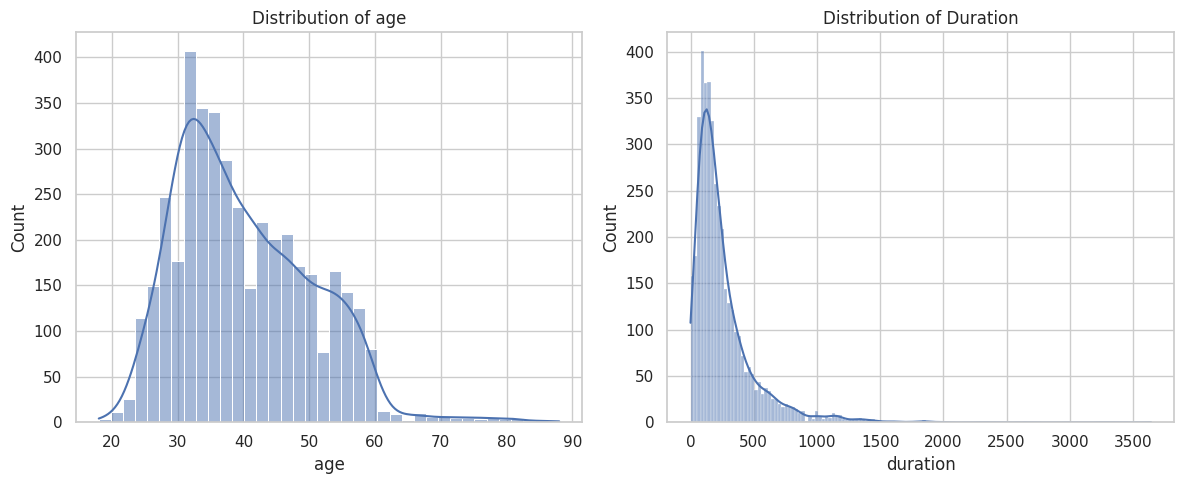

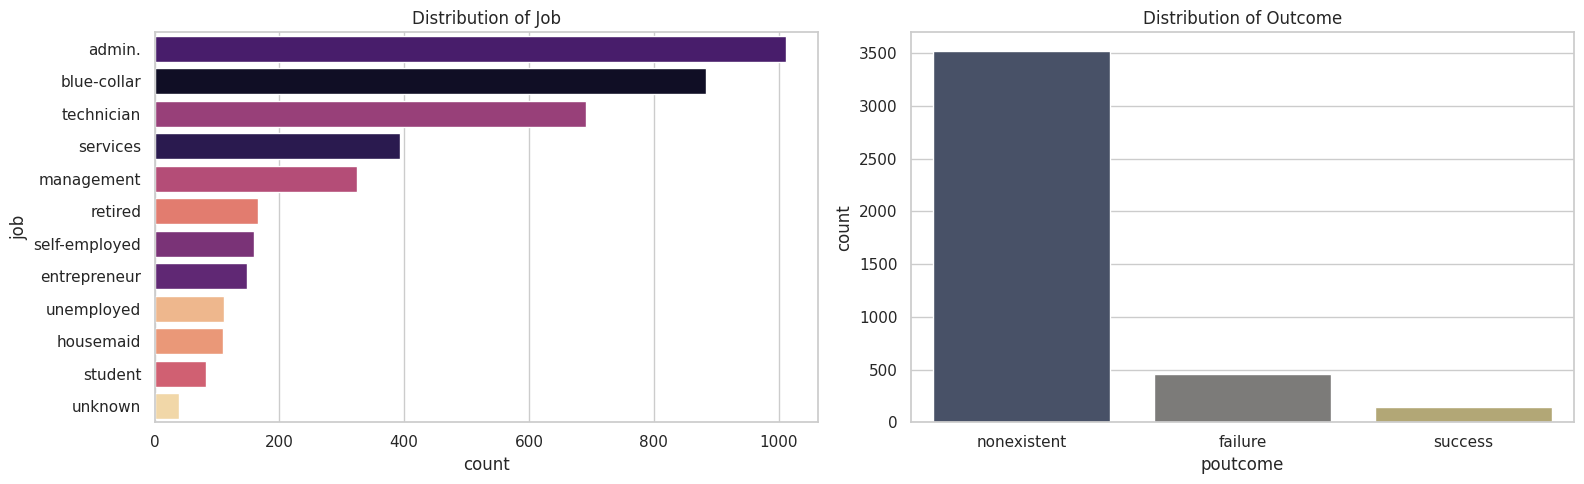

In [13]:
# Visualize distributions of two numerical variables
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of age')

plt.subplot(1, 2, 2)
sns.histplot(df['duration'], kde=True)
plt.title('Distribution of Duration')

plt.tight_layout()
plt.show()

# Visualize distributions of two categorical variables
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='job', data=df, order=df['job'].value_counts().index, palette='magma', hue='job', legend=False)
plt.title('Distribution of Job')

plt.subplot(1, 2, 2)
sns.countplot(x='poutcome', data=df, palette='cividis', hue='poutcome', legend=False)
plt.title('Distribution of Outcome')

plt.tight_layout()
plt.show()

Given the visualisations above, duration appears to require special consideration due to its extreme right-skewness. It is also important to consider potential data leakage from the duration variable. Call duration would have been obtained after the call, meaning potentially  already knowing the clients' decision. This could be labelled as temporal leakage since the information of call duration is not available at prediction time.

The default variable has the highest unknown entries. It must be considered as potential implicit missingness, and therefore imputed or dealt with accordingly.

Also, as seen from the csv file, pdays has multiple 999 entries. The value seems to suggest it is a code instead of a numeric value, and if this is not considered - it could be very misleading. Visualising the data may help to consider best-next options, as done below.

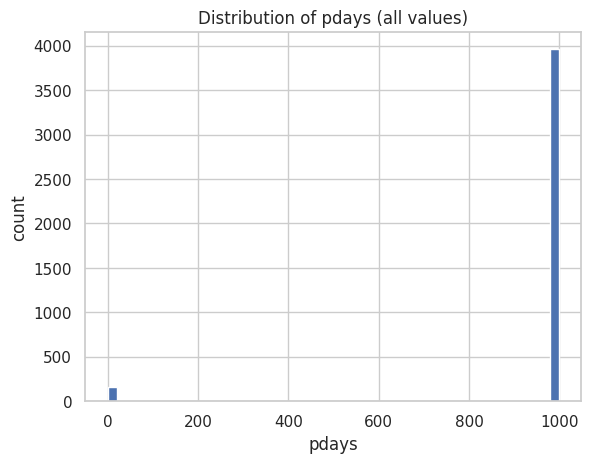

In [14]:
plt.figure()
plt.hist(df["pdays"], bins=50)
plt.title("Distribution of pdays (all values)")
plt.xlabel("pdays")
plt.ylabel("count")
plt.show()

As expected, there is a large amount of 999 entries. The distribution is heavily dominated. A visualisation of the data excluding the entry 999 may provide a more meaningful distribution, as created below.

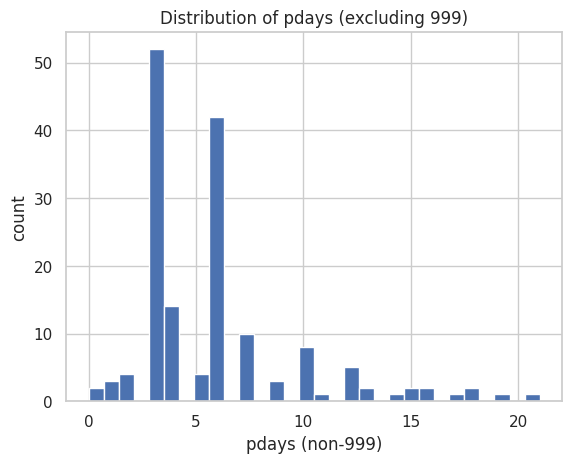

In [16]:
non_999 = df.loc[df["pdays"] != 999, "pdays"]

plt.figure()
plt.hist(non_999, bins=30)
plt.title("Distribution of pdays (excluding 999)")
plt.xlabel("pdays (non-999)")
plt.ylabel("count")
plt.show()

Results may suggest that 999 is a sentinel code, rather than a number of days since previously contacted. If we treat is as a continous variable, huge outliers will appear and the model will be biased. This variable needs to be hevaily considered, and potentially manipulated.

**Task: Task Ordering
Lecture material: Lecture 2 (Data Splitting and Leakage), Lecture 5 (Preprocessing), Lecture 9 (ML Pipeline).
• Determine the correct order in which the data preparation tasks in this assignment should be performed.
• Provide a structured justification for your chosen order.
• For each step in your proposed sequence, explain:
– what information is allowed to be used at that stage;
– what information must not be used;
– what type of data leakage could occur if the order were changed.
• Discuss at least one example of an incorrect ordering and explain the consequences it would have on model
evaluation.**

**Task: Data Splitting
Lecture material: Lecture 2 (Data Splitting and Leakage), Lecture 9 (ML Pipeline).
• Split the dataset into training, validation, and test sets.
• Justify your choice of proportions for each split.
• Perform stratified splitting with respect to the target variable and explain why stratification is necessary for
this dataset.
• Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage
would arise if splitting were performed later.
Note: A recommended strategy is to first split the dataset into a training set and a temporary set, and then
split the temporary set into validation and test sets. Use the stratify argument of train test split where
appropriate.**

In [17]:
# Separate features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

# First split: Create training set and a temporary set (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Divide the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Display the shapes of the splits
print("Dataset splits:")
display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test)

# Verify stratification for the target variable in each split
print("\nTarget variable distribution in each split:")
print("Train set 'y' distribution:")
display(y_train.value_counts(normalize=True))
print("\nValidation set 'y' distribution:")
display(y_val.value_counts(normalize=True))
print("\nTest set 'y' distribution:")
display(y_test.value_counts(normalize=True))

Dataset splits:


Set,X shape,y shape
Train,"(2883, 20)","(2883,)"
Validation,"(618, 20)","(618,)"
Test,"(618, 20)","(618,)"



Target variable distribution in each split:
Train set 'y' distribution:


,proportion
y,
no,0.890392
yes,0.109608



Validation set 'y' distribution:


,proportion
y,
no,0.889968
yes,0.110032



Test set 'y' distribution:


,proportion
y,
no,0.891586
yes,0.108414


Since the dataset is of medium-size, the choice of split would usually range between a 80/20/20 or a 70/15/15. Using the rule of thumb that there should be 12 per class minimum, and 100 to be reliable for the validation and test sets. Since the 'y' target only has around 10% positive values, splitting them using 80/20/20 would leave the validation/test sets with only 45 positive values. Hence, the 70/15/15 splitting proportions were chosen so that our future statistics are reliable.
Since our target variable 'y' is imbalanced, approx 10% are positive, we must use startification. Each split will have the same proportion of positive and negative values for the 'y' target variable. Our evaluation of the model therefore will mantain reliable and unbiased, which it would otherwise compromise.